# Классы nn.Linear и nn.Module

In [23]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

## Теория

In [24]:
class NetGirl(nn.Module):
    def __init__(self, input_dim, num_hidden, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, num_hidden)
        self.layer2 = nn.Linear(num_hidden, output_dim)
 
    def forward(self, x):
        x = self.layer1(x)
        x = F.tanh(x)
        x = self.layer2(x)
        x = F.tanh(x)
        return x

In [25]:
model = NetGirl(3, 2, 1) # число входов 3; число нейронов 2 и 1
model1 = NetGirl(3, 5, 2) # число входов 3; число нейронов 5 и 2
model2 = NetGirl(100, 18, 10) # число входов 100; число нейронов 18 и 10

In [26]:
print(model)

NetGirl(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)


In [27]:
gen_p = model.parameters() # возвращает генератор с набором параметров
print(list(model.parameters())) # отображение списка параметров

[Parameter containing:
tensor([[-0.3079, -0.5443,  0.1830],
        [-0.0312, -0.2945,  0.0176]], requires_grad=True), Parameter containing:
tensor([ 0.5010, -0.3744], requires_grad=True), Parameter containing:
tensor([[-0.6932, -0.3548]], requires_grad=True), Parameter containing:
tensor([-0.0126], requires_grad=True)]


In [28]:
x_train = torch.FloatTensor([(-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1),
                            (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1)])
y_train = torch.FloatTensor([-1, 1, -1, 1, -1, 1, -1, -1])
total = len(y_train)

optimizer = optim.RMSprop(params=model.parameters(), lr=0.01)
loss_func = torch.nn.MSELoss()

In [29]:
for _ in range(1000):
    k = np.random.randint(0, total-1)
    y = model(x_train[k])
    loss = loss_func(y, y_train[k])
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

c:\Users\Kurosawa\inchimonsha\main\AI\dl_practice\venv\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [30]:
model.eval()

NetGirl(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)

In [31]:
for x, d in zip(x_train, y_train):
    y = model(x)
    print(f"Выходное значение НС: {y.data} => {d}")

Выходное значение НС: tensor([-0.9925]) => -1.0
Выходное значение НС: tensor([0.9927]) => 1.0
Выходное значение НС: tensor([-0.9933]) => -1.0
Выходное значение НС: tensor([0.9926]) => 1.0
Выходное значение НС: tensor([-0.9932]) => -1.0
Выходное значение НС: tensor([0.9930]) => 1.0
Выходное значение НС: tensor([-0.9936]) => -1.0
Выходное значение НС: tensor([0.9925]) => -1.0


In [ ]:
import torch
import torch.nn as nn

layer = nn.Linear(54, 10)
print(layer.weight)
print(layer.bias)

batch_size = 8
x = torch.rand(batch_size, 54)
u = layer(x)

Parameter containing:
tensor([[-0.0216,  0.0156,  0.1230, -0.0312,  0.1187,  0.0368,  0.0721, -0.0939,
          0.1335, -0.0185,  0.1212,  0.1251, -0.0676, -0.0403, -0.0920, -0.0261,
          0.0926, -0.0565, -0.0324, -0.1017, -0.0624, -0.0643,  0.0202, -0.0390,
         -0.0294,  0.0252, -0.0251,  0.0323, -0.0190,  0.0419,  0.1193, -0.0480,
         -0.0703,  0.0422,  0.0414,  0.0406, -0.0500,  0.1066, -0.0207,  0.0414,
         -0.0654,  0.0986,  0.0938, -0.0704,  0.0689,  0.0922,  0.0767, -0.0018,
          0.1181, -0.1044, -0.0979, -0.0149,  0.0388,  0.1275],
        [-0.0346,  0.1101, -0.0785,  0.0734, -0.1146,  0.0316,  0.0082,  0.0429,
          0.0648, -0.1274,  0.0679, -0.0455, -0.0145, -0.1019,  0.1019,  0.0683,
         -0.0915, -0.1186,  0.0825, -0.0448, -0.0987,  0.0074,  0.0157, -0.0860,
          0.0021, -0.1084, -0.0104, -0.0899, -0.1140,  0.0844, -0.0310,  0.1149,
          0.0356, -0.0882,  0.0177,  0.0405,  0.0588, -0.0133, -0.1343, -0.1046,
         -0.0035,  0.10

tensor([[ 0.2244, -0.2460,  0.0455, -0.4936, -0.0366, -0.2781, -0.2551,  0.5686,
         -0.4332, -0.7505],
        [ 0.4146, -0.4331, -0.1223, -0.1256,  0.0018,  0.0835, -0.4360,  0.5270,
         -0.5105, -0.6734],
        [ 0.2822, -0.4409,  0.2675, -0.1773, -0.0758,  0.0604, -0.3388,  0.4588,
         -0.2464, -0.5524],
        [ 0.1407, -0.1596,  0.1677,  0.3183, -0.1737,  0.3909, -0.4890,  0.7071,
         -0.0188, -0.9162],
        [ 0.2374, -0.2209,  0.2226,  0.1431, -0.1356,  0.5633, -0.4106,  0.2883,
         -0.3957, -0.6873],
        [ 0.3196, -0.4977, -0.0229, -0.5844, -0.1713, -0.0232, -0.2912,  0.4056,
         -0.4770, -0.4383],
        [ 0.2128, -0.2380,  0.1357, -0.1336, -0.2238,  0.2404, -0.2543,  0.1527,
         -0.4216, -0.2997],
        [ 0.1487, -0.4459,  0.0507, -0.1920, -0.0061,  0.4623, -0.3823,  0.6114,
         -0.0709, -0.9977]], grad_fn=<AddmmBackward0>)

В PyTorch, когда вы видите вывод вида:
    tensor([[-0.4497,  0.5675]], grad_fn=<AddmmBackward0>)

это значит следующее:

    tensor([...]) — это сам тензор с числовыми значениями.

    grad_fn=<AddmmBackward0> — это ссылка на функцию обратного распространения (backward function), которая отвечает за вычисление градиентов для этого тензора при вызове .backward().

        Здесь AddmmBackward0 указывает, что тензор был получен как результат операции torch.addmm(), то есть операции, которая выполняет матричное умножение с добавлением (обычно это x @ W^T + b в линейном слое).

    Такой атрибут появляется, когда requires_grad=True для тензора либо для входящих в операцию тензоров. Это создаёт вычислительный граф для автоматического дифференцирования.

Подробнее о поведении упомянутых элементов:

    ViewBackward0 — функциональный узел, который изменяет форму тензора (view, reshape). Он "перекидывает" градиент нужной формы назад по графу без сложных вычислений.

    AddmmBackward0 — один из ключевых вычислительных узлов, который отвечает за обратное распространение градиентов через операцию матричного умножения с добавлением. Этот узел реально вычисляет производные при backpropagation.

Зачем это нужно? Когда вы строите нейросеть и вызываете loss.backward(), PyTorch проходит по этому вычислительному графу, начиная с конечного тензора ошибки, вызывая функции, на которые указывают атрибуты grad_fn, для вычисления градиентов параметров. Это обеспечивает автоматическое и эффективное вычисление производных по всем параметрам модели.

---
Создайте в программе модель двухслойной нейронной сети в виде класса TwoLayerModel на базе класса nn.Module, в соответствии со следующим рисунком:

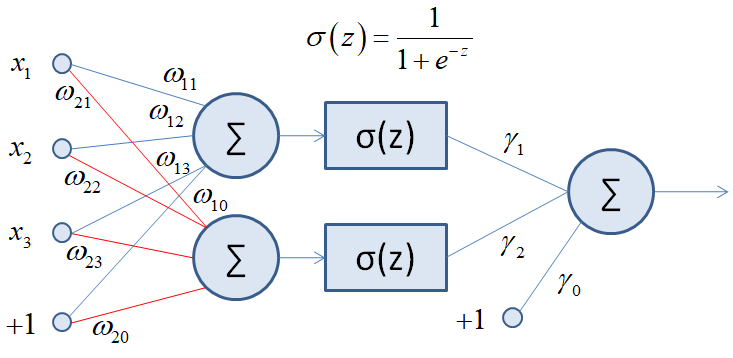

In [ ]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели (обязательно до тензора x)
class TwoLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 2)
        self.layer2 = nn.Linear(2, 1)
        self.sigm = nn.Sigmoid()
        
    def forward(self, x):
        # 1 way
        # x = self.layer1(x)
        # x = F.sigmoid(x)
        # 2 way
        # x = self.layer1(x).sigmoid()
        # 3 way
        x = self.layer1(x)
        x = self.sigm(x)
        
        x = self.layer2(x)
        return x

x = torch.rand(3) # тензор x в программе не менять

# здесь продолжайте программу
model = TwoLayerModel()
model.eval()
predict = model(x)
print(predict)

tensor([0.6620], grad_fn=<ViewBackward0>)


In [ ]:
# model.train() # переводит модель в режим обучения
# model.eval() # переводит модель в режим эксплуатации
# model.requires_grad_() # включает/отключает градиенты параметров модели

list(model.parameters()) # возвращает генератор для получения набора весовых коэффициентов сети (модели)

[Parameter containing:
 tensor([[ 0.3211,  0.5665, -0.0966],
         [ 0.4528,  0.0218, -0.4130]], requires_grad=True),
 Parameter containing:
 tensor([0.4125, 0.0643], requires_grad=True),
 Parameter containing:
 tensor([[0.6541, 0.3160]], requires_grad=True),
 Parameter containing:
 tensor([0.0845], requires_grad=True)]

---
Объявите в программе модель ThreeLayersModel на базе класса nn.Module с тремя полносвязными слоями. Слои следует регистрировать (создавать) в порядке:

    первый (скрытый) слой;
    второй (скрытый) слой;
    выходной слой.

В методе forward() пропустите входной тензор последовательно через эти слои, применяя функцию активации torch.tanh() на выходах каждого слоя (включая выходной).

In [ ]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели (обязательно до тензора x)
class ThreeLayersModel(nn.Module):
    def __init__(self, input_dim, num_hidden_1, num_hidden_2, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, num_hidden_1)
        self.layer2 = nn.Linear(num_hidden_1, num_hidden_2)
        self.layer3 = nn.Linear(num_hidden_2, output_dim)
        
    def forward(self, x):
        x = self.layer1(x).tanh()
        x = self.layer2(x).tanh()
        x = self.layer3(x).tanh()
        return x

batch_size = 4
x = torch.rand(batch_size, 32) # тензор x в программе не менять

# здесь продолжайте программу
model = ThreeLayersModel(32, 10, 12, 1)
model.eval()
predict = model(x)
print(predict)

tensor([[0.5504],
        [0.5500],
        [0.5657],
        [0.5509]], grad_fn=<TanhBackward0>)


In [ ]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели (обязательно до тензора x_train)
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 3)
        self.layer2 = nn.Linear(3, 1)
        
    def forward(self, x):
        x = self.layer1(x).tanh()
        x = self.layer2(x).sigmoid()
        return x

# тензор x_train в программе не менять
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])

# здесь продолжайте программу
model = Model()
model.eval()

predict = []

for X in x_train:
    with torch.no_grad():
        y = model(X)
        predict.append(y.item())

print(predict)

[0.825036346912384, 0.823590099811554, 0.8314515948295593, 0.8280317783355713, 0.8304260969161987, 0.8380036950111389, 0.8278387188911438, 0.8231917023658752, 0.82764732837677, 0.8260336518287659, 0.825045645236969, 0.8299893736839294, 0.8295184969902039, 0.8380023241043091, 0.825036346912384, 0.8302980065345764, 0.826436460018158, 0.8288688063621521, 0.8242534399032593, 0.8303498029708862, 0.8328953385353088, 0.8218268156051636, 0.8132143616676331, 0.8282163739204407, 0.82764732837677, 0.8357338905334473, 0.8362733721733093, 0.8319941759109497, 0.8239935636520386, 0.8212326169013977, 0.8310844898223877, 0.8231917023658752, 0.8318389058113098, 0.8343245983123779, 0.8337464332580566, 0.8242534399032593, 0.8344140648841858, 0.8282163739204407, 0.8286993503570557, 0.8329818844795227, 0.8275092840194702, 0.8317451477050781, 0.8307384252548218, 0.8339757919311523, 0.8231917023658752, 0.8326447606086731, 0.8260336518287659, 0.829666256904602, 0.8331379890441895, 0.8294735550880432, 0.8301684

In [50]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# здесь объявляйте класс TriagModel
class TriagModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 1, bias=False)
        
    def forward(self, x):
        x = self.layer1(x)
        return x

np.random.seed(1)
torch.manual_seed(1)

total = 100
x_train = torch.randint(1, 10, (total, 3), dtype=torch.float32)
y_train = x_train.sum(dim=1) / 3

# здесь создавайте модель (model)
model = TriagModel()
# переведите модель в режим обучения
model.eval()

lr = 0.01 # шаг обучения
N = 1000 # число итераций SGD

optimizer = optim.Adam(params=model.parameters(), lr=lr) # здесь сформируйте оптимизатор Adam с параметрами модели и шагом обучения lr
loss_func = nn.MSELoss() # здесь создайте функцию потерь с помощью класса nn.MSELoss

for _ in range(N):
    k = np.random.randint(0, total)
    # пропустите через модель k-й образ выборки x_train и вычислите прогноз predict
    predict = model(x_train[k])
    loss = loss_func(y_train[k], predict) # вычислите значение функции потерь и сохраните результат в переменной loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(predict, loss)

tensor([3.6667], grad_fn=<SqueezeBackward4>) tensor(1.0669e-09, grad_fn=<MseLossBackward0>)


c:\Users\Kurosawa\inchimonsha\main\AI\dl_practice\venv\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [109]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# здесь объявляйте класс ClassModel
class ClassModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 3)
        self.layer2 = nn.Linear(3, 1)
        
    def forward(self, x):
        x = self.layer1(x).relu()
        x = self.layer2(x)
        return x

np.random.seed(1)
torch.manual_seed(1)

# обучающая выборка: x_train - входные значения; y_train - целевые значения
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])
y_train = torch.FloatTensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])

model = ClassModel() # здесь создавайте модель
# переведите модель в режим обучения
model.train()

total = x_train.size(0) # размер обучающей выборки
N = 1000 # число итераций алгоритма SGD

optimizer = optim.Adam(params=model.parameters(), lr=0.01) # задайте оптимизатор Adam с шагом обучения lr=0.01
loss_func = nn.BCEWithLogitsLoss() # сформируйте функцию потерь (бинарную кросс-энтропию) с помощью класса nn.BCEWithLogitsLoss

for _ in range(N):
    k = np.random.randint(0, total)
    # пропустите через модель k-й образ выборки x_train и вычислите прогноз predict
    predict = model(x_train[k])
    
    loss = loss_func(predict, y_train[k].unsqueeze(0)) # вычислите значение функции потерь и сохраните результат в переменной loss

    # выполните один шаг градиентного спуска так, как это было сделано в предыдущем подвиге
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
# predict = []
# # переведите модель в режим эксплуатации
# model.eval()
# # прогоните через модель обучающую выборку и подсчитайте долю верных классификаций
# for X in x_train:
#     with torch.no_grad():
#         y = model(X.unsqueeze(0))
#         predict.append((torch.sigmoid(y) > 0.5).float().item())
predict = (torch.sigmoid(model(x_train)) > 0.5).float().T

# результат (долю верных классификаций) сохраните в переменной Q (в виде вещественного числа, а не тензора)
Q = (y_train == torch.tensor(predict)).float().mean().item()
Q

C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_22108\296765198.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Q = (y_train == torch.tensor(predict)).float().mean().item()


0.8899999856948853

In [132]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# сюда скопируйте класс ClassModel из предыдущего подвига
class ClassModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 3)
        self.layer2 = nn.Linear(3, 1)
        
    def forward(self, x):
        x = self.layer1(x).relu()
        x = self.layer2(x)
        return x

np.random.seed(1)
torch.manual_seed(1)

# обучающая выборка: x_train - входные значения; y_train - целевые значения
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])
y_train = torch.FloatTensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])

model = ClassModel() # здесь создавайте модель
# переведите модель в режим обучения
model.train()

total = x_train.size(0) # размер обучающей выборки
N = 1000 # число итераций алгоритма SGD
batch_size = 8 # размер мини-батча

optimizer = optim.Adam(params=model.parameters(), lr=0.01) # задайте оптимизатор Adam с шагом обучения lr=0.01
loss_func = nn.BCEWithLogitsLoss() # сформируйте функцию потерь (бинарную кросс-энтропию) с помощью класса nn.BCEWithLogitsLoss

for _ in range(N):
    idx = np.random.choice(total, batch_size, False) # выбор индексов образов в размере batch_size
    # с помощью списочной индексации отберите из выборки x_train образы согласно индексам списка idx
    # x_choice = x_train[idx]
    # y_choice = x_train[idx]
    # пропустите через модель батч образов выборки и вычислите батч прогнозов predict
    predict = model(x_train[idx])
    loss = loss_func(predict.squeeze(), y_train[idx]) # вычислите значение функции потерь и сохраните результат в переменной loss
    # выполните один шаг градиентного спуска так, как это было сделано в предыдущем подвиге
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# переведите модель в режим эксплуатации
model.eval()
# прогоните через модель обучающую выборку и подсчитайте долю верных классификаций
predict = (torch.sigmoid(model(x_train)) > 0.5).float().t()

# результат (долю верных классификаций) сохраните в переменной Q (в виде вещественного числа, а не тензора)
Q = (y_train == torch.tensor(predict)).float().mean().item()
Q

C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_22108\1097035845.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Q = (y_train == torch.tensor(predict)).float().mean().item()


0.9300000071525574

torch.Size([8])

C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_22108\2602648077.py:1: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  y_train[[idx]].size()


torch.Size([8])